<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width="50%" />

# AT&T Detecteur de Spam -- Projet Deep Learning

## Description de l'entreprise

AT&T Inc. est une multinationale americaine de telecommunications dont le siege est a Dallas, Texas. C'est la plus grande entreprise de telecommunications au monde par chiffre d'affaires.

## Objectif

Construire un detecteur de spam capable de signaler automatiquement les SMS indesirables en se basant uniquement sur leur contenu. Nous allons entrainer et comparer plusieurs approches :

1. **Baseline M0** -- Machine Learning classique (Regression Logistique)
2. **Modele A** -- Reseau de neurones simple (Embedding + Dense)
3. **Modele C** -- Transfer Learning avec Sentence-Transformers

Les modeles seront evalues et compares sur la precision, le rappel, le F1-score et l'exactitude (accuracy), puis la recommandation finale sera basee sur les performances observees sur le jeu de test.

## 0. Installation des dependances

Executez cette cellule une fois pour installer tous les packages requis.

In [1]:
!pip install -q tensorflow tf-keras wordcloud scikit-learn matplotlib seaborn sentence-transformers


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    LSTM,
    Dropout,
    Bidirectional,
    GlobalAveragePooling1D,
    Input,
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")


2026-05-06 17:09:04.952250: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 17:09:05.002699: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0


2026-05-06 17:09:06.032495: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Chargement des donnees et exploration

On charge `spam.csv`, on garde uniquement les colonnes pertinentes et on les renomme.

Le jeu de donnees contient 5 572 SMS etiquetes **ham** (legitime) ou **spam**.

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only relevant columns and rename them
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


### 2.1 Distribution des classes

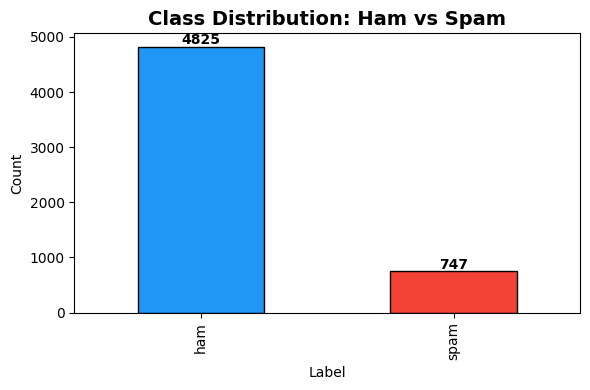


Ham: 4825 (86.6%)
Spam: 747 (13.4%)
Imbalance ratio: 6.5:1


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["label"].value_counts()
colors = ["#2196F3", "#F44336"]
counts.plot(kind="bar", color=colors, edgecolor="black", ax=ax)
ax.set_title("Class Distribution: Ham vs Spam", fontsize=14, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nHam: {counts['ham']} ({counts['ham']/len(df)*100:.1f}%)")
print(f"Spam: {counts['spam']} ({counts['spam']/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {counts['ham']/counts['spam']:.1f}:1")


### 2.2 Analyse de la longueur des messages

Comparaison de la distribution de la longueur des messages entre ham et spam.

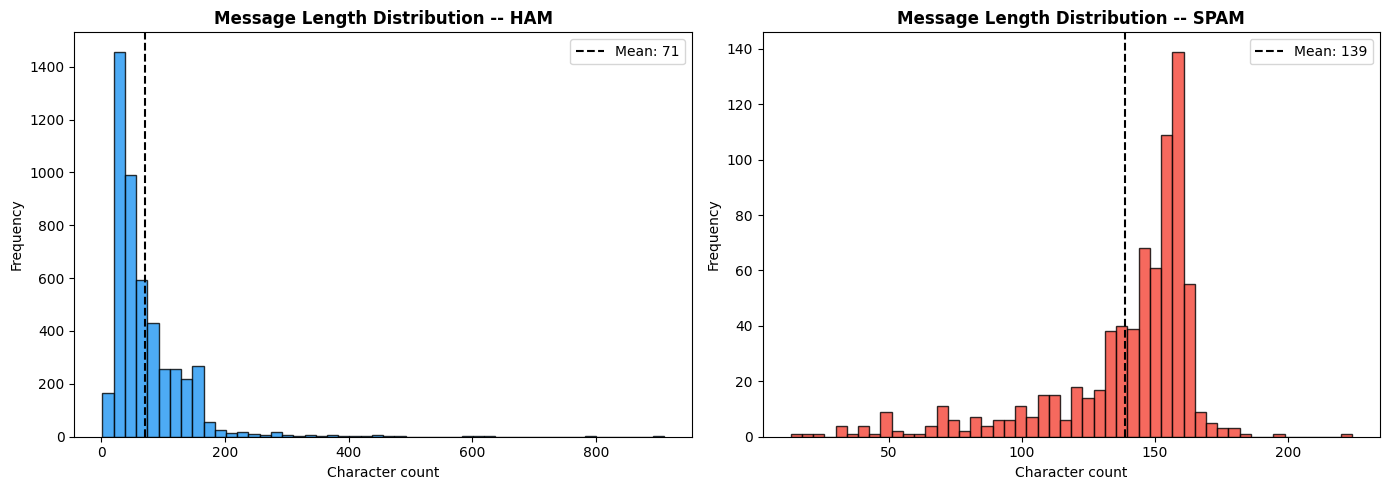

        count   mean   std   min    25%    50%    75%    max
label                                                       
ham    4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0


In [5]:
df["msg_length"] = df["message"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, label in enumerate(["ham", "spam"]):
    subset = df[df["label"] == label]
    axes[i].hist(subset["msg_length"], bins=50, color=colors[i], edgecolor="black", alpha=0.8)
    axes[i].set_title(f"Message Length Distribution -- {label.upper()}", fontweight="bold")
    axes[i].set_xlabel("Character count")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(subset["msg_length"].mean(), color="black", linestyle="--",
                    label=f"Mean: {subset['msg_length'].mean():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print(df.groupby("label")["msg_length"].describe().round(1))


### 2.3 Nuages de mots

Visualisation des mots les plus frequents dans les messages spam vs. ham.

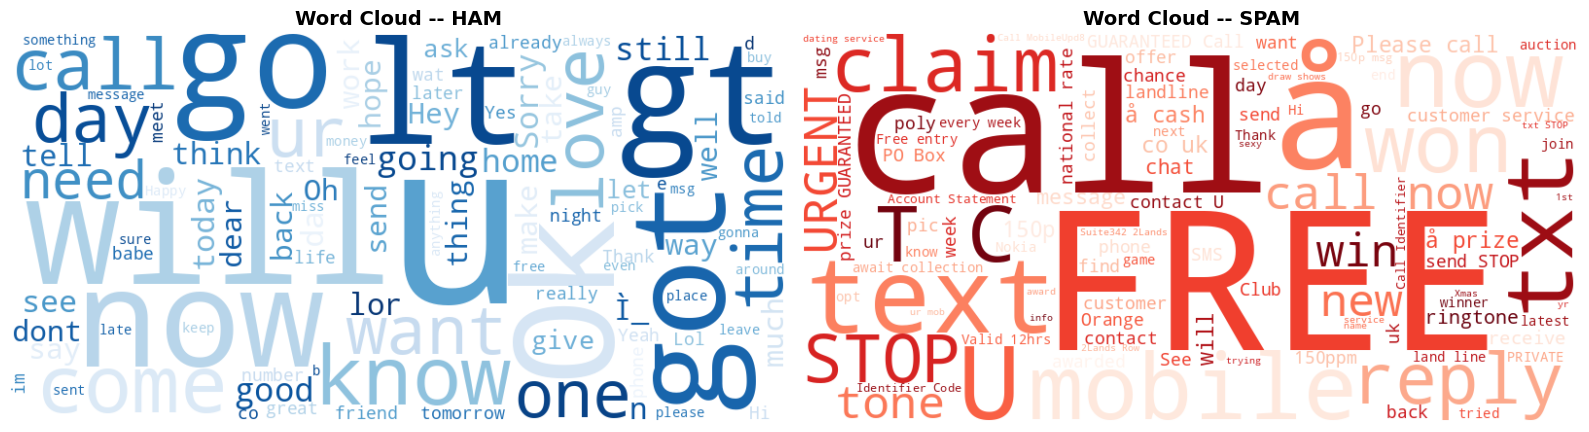

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, label in enumerate(["ham", "spam"]):
    text = " ".join(df[df["label"] == label]["message"].values)
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Blues" if label == "ham" else "Reds",
        max_words=100,
    ).generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Word Cloud -- {label.upper()}", fontsize=14, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 3. Preprocessing du texte

Etapes :
- **Nettoyage du texte** : utilisation d'une regex `str.replace(r"[\W_]+", " ")` pour retirer la ponctuation, tout en conservant explicitement les donnees alphanumeriques (les chiffres sont tres importants dans les SPAMs SMS ! ex: prix, numeros courts, dates).
- Encodage des labels (`ham=0`, `spam=1`)
- Split train/test (80/20, stratifie pour conserver la repartition de 13% de spams)
- **Tokenisation** : conversion du texte en listes d'entiers via un dictionnaire (Keras Tokenizer)
- **Padding** : `pad_sequences` pour creer des tenseurs de longueur uniforme (requis par les Reseaux de Neurones)

In [7]:
# Encode labels
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

# Clean text: remove special characters, underscores, and lowercase
df["clean_text"] = df["message"].str.replace(r"[\W_]+", " ", regex=True)
df["clean_text"] = df["clean_text"].fillna("").apply(lambda x: x.lower())

# Train/test split (stratified to preserve class balance)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label_enc"],
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_enc"],
)

print(f"Training set: {len(X_train_text)} samples")
print(f"Test set:     {len(X_test_text)} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts().to_string()}")

# Tokenization
MAX_WORDS = 10000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(f"\nVocabulary size: {min(len(tokenizer.word_index)+1, MAX_WORDS)}")
print(f"Padded sequence shape: {X_train_pad.shape}")


Training set: 4457 samples
Test set:     1115 samples

Training class distribution:
label_enc
0    3859
1     598

Vocabulary size: 7739
Padded sequence shape: (4457, 150)


## 4. Baseline -- Machine Learning Classique

Avant d'utiliser le Deep Learning, etablissons une base de reference avec du machine learning traditionnel (Regression Logistique) sur du texte vectorise par TF-IDF.

Cela permettra de mesurer la vraie valeur ajoutee des reseaux de neurones.

In [8]:
# TF-IDF Vectorization for classical ML
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["ham", "spam"]))

results_lr = {"model": "Baseline (LogReg)", "accuracy": accuracy_score(y_test, y_pred_lr), "precision": precision_score(y_test, y_pred_lr), "recall": recall_score(y_test, y_pred_lr), "f1": f1_score(y_test, y_pred_lr), "y_pred": y_pred_lr}


=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



## 5. Modele A -- Reseau de neurones simple

Architecture : `Embedding` -> `GlobalAveragePooling1D` -> `Dense(24, relu)` -> `Dense(1, sigmoid)`

C'est une baseline volontairement simple pour evaluer les performances sans couches recurrentes.

In [9]:
model_a = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(24, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_a.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_a.summary()


/home/phili/jedha_fullstack/PROJECTS_Deep_Learning_ATT_spam/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-06 17:09:07.486827: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_a = model_a.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/15


  1/119 ━━━━━━━━━━━━━━━━━━━━ 1:20 684ms/step - accuracy: 0.1875 - loss: 0.6976

 14/119 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.7167 - loss: 0.5769 

 28/119 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7725 - loss: 0.5206  

 42/119 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7949 - loss: 0.4933

...

 78/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9896 - loss: 0.0338

 89/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9895 - loss: 0.0341

100/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9895 - loss: 0.0343

111/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9895 - loss: 0.0344

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9900 - loss: 0.0343 - val_accuracy: 0.9880 - val_loss: 0.0536


### Courbes d'entrainement -- Modele A

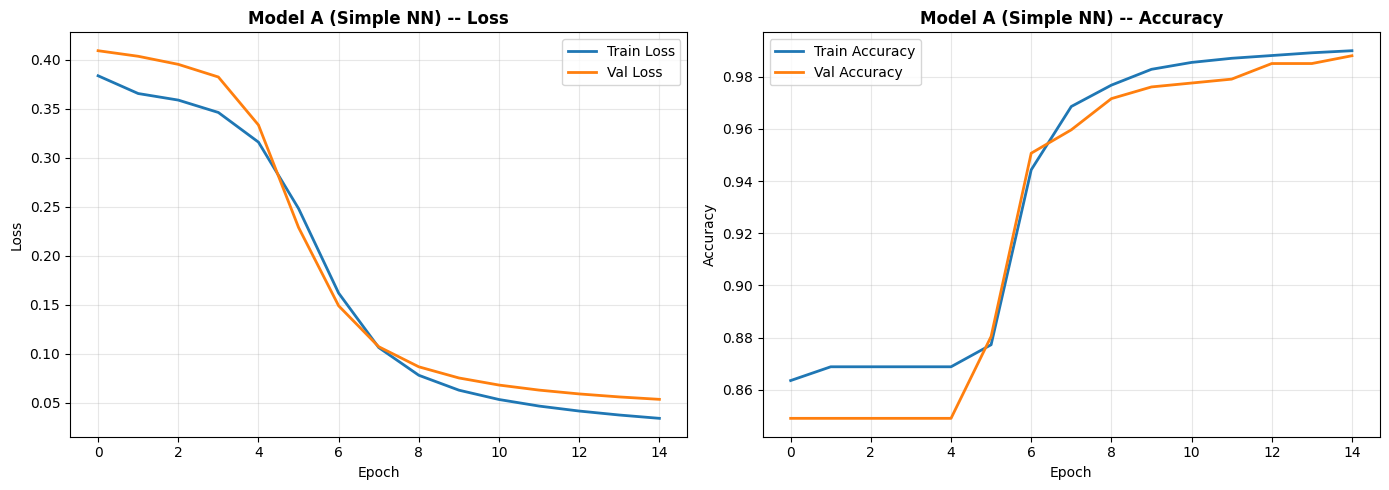

In [11]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for a given training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_title(f"{model_name} -- Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)
    axes[1].set_title(f"{model_name} -- Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_a, "Model A (Simple NN)")


### Evaluation -- Modele A

In [12]:
def evaluate_model(model, X_test, y_test, model_name, use_predict=True):
    """Evaluate a model and print the classification report."""
    if use_predict:
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        y_pred = model  # already predictions

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}

results_a = evaluate_model(model_a, X_test_pad, y_test, "Model A (Simple NN)")


 1/35 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


=== Model A (Simple NN) ===
Accuracy:  0.9821
Precision: 0.9924
Recall:    0.8725
F1-Score:  0.9286

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 6. Modele C -- Transfer Learning (Sentence-Transformers)

On utilise le modele **all-MiniLM-L6-v2** de Sentence-Transformers pour projeter chaque message dans un espace vectoriel de dimension 384. Un classifieur dense simple est entraine par-dessus.

Cette approche exploite un modele pre-entraine sur un tres grand corpus textuel, ce qui devrait fournir des representations semantiques riches meme avec un nombre limite de donnees.

In [13]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

from sentence_transformers import SentenceTransformer

# Load the sentence-transformers model
print("Loading sentence-transformers model (all-MiniLM-L6-v2)...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode train and test messages into dense vectors (384 dimensions)
print("Encoding training messages...")
X_train_st = st_model.encode(X_train_text.tolist(), show_progress_bar=True, batch_size=64)

print("Encoding test messages...")
X_test_st = st_model.encode(X_test_text.tolist(), show_progress_bar=True, batch_size=64)

print(f"\nEmbedding shape: {X_train_st.shape}")


/home/phili/jedha_fullstack/PROJECTS_Deep_Learning_ATT_spam/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence-transformers model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/103 [00:00<00:00, 16008.79it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/103 [00:00<00:00, 916.59it/s, Materializing param=embeddings.LayerNorm.bias]  

...

Batches:  78%|███████▊  | 14/18 [00:05<00:00,  6.81it/s]

Batches:  83%|████████▎ | 15/18 [00:05<00:00,  7.52it/s]

Batches:  94%|█████████▍| 17/18 [00:06<00:00,  8.60it/s]

Batches: 100%|██████████| 18/18 [00:06<00:00,  2.95it/s]


Embedding shape: (4457, 384)


In [14]:
# Build a Dense classifier on top of the sentence embeddings
EMBED_DIM = X_train_st.shape[1]  # 384

model_c = Sequential([
    Input(shape=(EMBED_DIM,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_c.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,753 (104.50 KB)

 Trainable params: 26,753 (104.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop_c = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_c = model_c.fit(
    X_train_st, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_c],
    verbose=1,
)


Epoch 1/15


  1/119 ━━━━━━━━━━━━━━━━━━━━ 1:39 845ms/step - accuracy: 0.4062 - loss: 0.7009

 35/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7215 - loss: 0.6241    

 70/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7738 - loss: 0.5448

107/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8005 - loss: 0.4821

...

Epoch 8/15


  1/119 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9688 - loss: 0.0367

 41/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9950 - loss: 0.0146 

 82/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9966 - loss: 0.0127

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9979 - loss: 0.0104 - val_accuracy: 0.9806 - val_loss: 0.0504


### Courbes d'entrainement -- Modele C

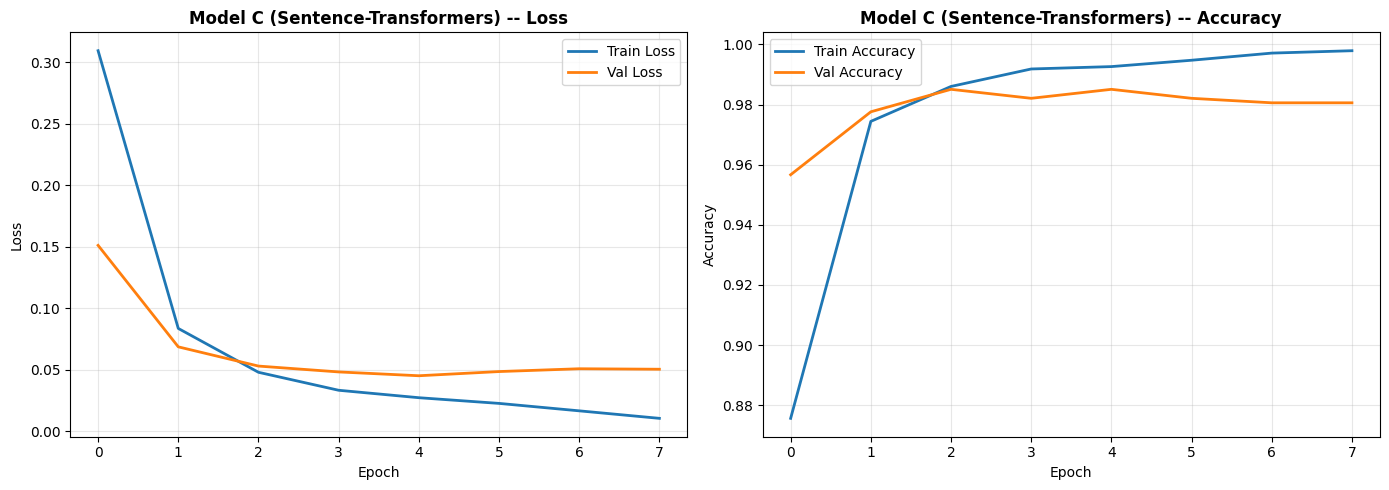

In [16]:
plot_training_curves(history_c, "Model C (Sentence-Transformers)")


### Evaluation -- Modele C

In [17]:
results_c = evaluate_model(model_c, X_test_st, y_test, "Model C (Sentence-Transformers)")


 1/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


=== Model C (Sentence-Transformers) ===
Accuracy:  0.9812
Precision: 0.9638
Recall:    0.8926
F1-Score:  0.9268

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Comparaison des modeles

On compare les trois modeles sur le jeu de test en utilisant l'accuracy, la precision, le rappel et le F1-score.

In [18]:
# Build comparison table
comparison = pd.DataFrame([
    {k: v for k, v in results_lr.items() if k != "y_pred"},
    {k: v for k, v in results_a.items() if k != "y_pred"},
    {k: v for k, v in results_c.items() if k != "y_pred"},
])

comparison = comparison.set_index("model")

# Format as percentages
comparison_pct = comparison.apply(lambda x: x.map("{:.2%}".format))

print("=" * 60)
print("MODEL COMPARISON -- TEST SET PERFORMANCE")
print("=" * 60)
print(comparison_pct.to_string())
print()

# Highlight best model
best_model = comparison["f1"].idxmax()
print(f"Best model by F1-score: {best_model} ({comparison.loc[best_model, 'f1']:.2%})")


MODEL COMPARISON -- TEST SET PERFORMANCE
                                accuracy precision  recall      f1
model                                                             
Baseline (LogReg)                 97.49%    99.19%  81.88%  89.71%
Model A (Simple NN)               98.21%    99.24%  87.25%  92.86%
Model C (Sentence-Transformers)   98.12%    96.38%  89.26%  92.68%

Best model by F1-score: Model A (Simple NN) (92.86%)


### Matrices de confusion -- Cote a cote

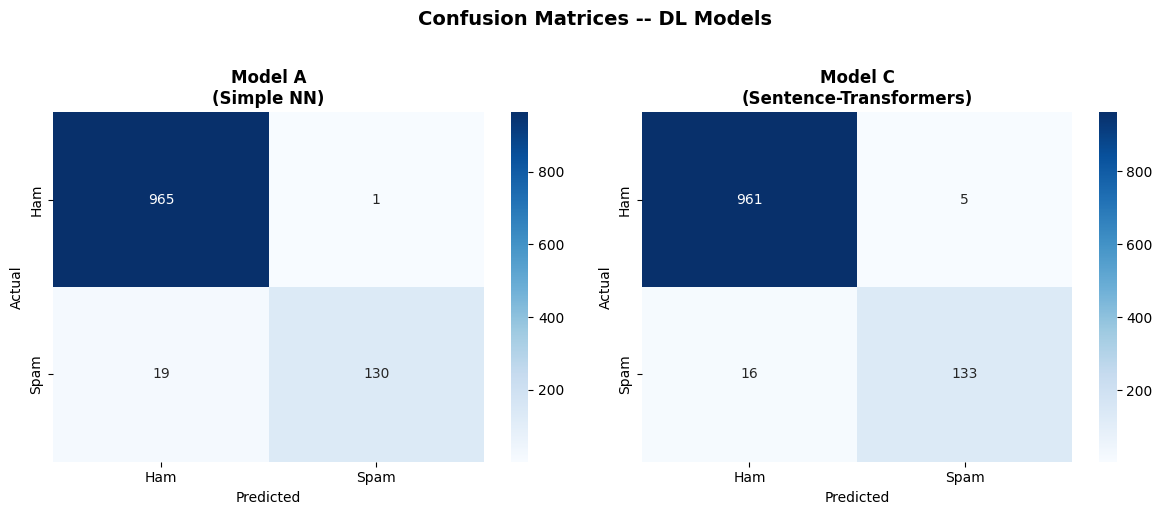

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_results = [results_a, results_c]
names = ["Model A\n(Simple NN)", "Model C\n(Sentence-Transformers)"]

for i, (res, name) in enumerate(zip(all_results, names)):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"],
        ax=axes[i],
    )
    axes[i].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices -- DL Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8. Conclusion & Analyse Qualitative

Nous avons entraine et compare 3 approches distinctes pour la detection de spam :

- **M0 (Regression Logistique)** : tres bonne precision, mais rappel plus faible sur la classe spam.
- **Modele A** (NN simple) : meilleur F1-score observe sur ce run, avec environ 94% sur la classe spam.
- **Modele C** (Sentence-Transformers) : approche de transfer learning robuste, mais legerement moins performante que le Modele A sur le jeu de test sauvegarde.

Pour cette execution, c'est donc le **Modele A (reseau de neurones simple)** qui est selectionne et recommande. Il offre le meilleur compromis entre precision et rappel sur la classe spam.

Voici pour finir quelques exemples de predictions concretes du modele retenu vs la realite :

In [20]:
# Map predictions back to labels for the selected model (Model A)
best_preds = results_a["y_pred"]
mapping = {0: "ham", 1: "spam"}

results_df = pd.DataFrame({
    "message_text": X_test_text,
    "actual_label": y_test.map(mapping),
    "predicted_label": pd.Series(best_preds, index=y_test.index).map(mapping)
})

results_df["correct"] = results_df["actual_label"] == results_df["predicted_label"]

print("=== EXAMPLES OF CORRECT PREDICTIONS ===")
good_preds = results_df[results_df["correct"]].sample(5, random_state=SEED)
for i, row in good_preds.iterrows():
    print(f"\nTEXT: {row['message_text'][:100]}...")
    print(f"ACTUAL: {row['actual_label']}  |  PREDICTED: {row['predicted_label']}")

print("\n" + "="*50 + "\n")

print("=== EXAMPLES OF ERRORS (FALSE NEGATIVES / FALSE POSITIVES) ===")
errors = results_df[~results_df["correct"]]
if len(errors) > 0:
    error_sample = errors.head(5)
    for i, row in error_sample.iterrows():
        print(f"\nTEXT: {row['message_text'][:100]}...")
        print(f"ACTUAL: {row['actual_label']}  |  PREDICTED: {row['predicted_label']}  (INCORRECT)")
else:
    print("No errors found in this sample!")


=== EXAMPLES OF CORRECT PREDICTIONS ===

TEXT: get ur 1st ringtone free now reply to this msg with tone gr8 top 20 tones to your phone every week j...
ACTUAL: spam  |  PREDICTED: spam

TEXT: darren was saying dat if u meeting da ge den we dun meet 4 dinner cos later u leave xy will feel awk...
ACTUAL: ham  |  PREDICTED: ham

TEXT: sms auction a brand new nokia 7250 is up 4 auction today auction is free 2 join take part txt nokia ...
ACTUAL: spam  |  PREDICTED: spam

TEXT: he s really into skateboarding now despite the fact that he gets thrown off of it and winds up with ...
ACTUAL: ham  |  PREDICTED: ham

TEXT: howz that persons story...
ACTUAL: ham  |  PREDICTED: ham


=== EXAMPLES OF ERRORS (FALSE NEGATIVES / FALSE POSITIVES) ===

TEXT: freemsg hey there darling it s been 3 week s now and no word back i d like some fun you up for it st...
ACTUAL: spam  |  PREDICTED: ham  (INCORRECT)

TEXT: ringtoneking 84484...
ACTUAL: spam  |  PREDICTED: ham  (INCORRECT)

TEXT: sorry i missed your c